# Carbon Emissions Analysis

Two datasets are explored:
1. **Global Carbon Budget 2023** — total fossil CO₂ emissions by category (Global Carbon Budget)
2. **Carbon Majors** — emissions attributed to 122 of the world's largest producers

We create stacked bar charts, percentage fill charts, and a treemap.



In [3]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
import tempfile
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Try to import squarify for treemaps; install hint if missing
try:
    import squarify
except ImportError:
    print('squarify not found. Install with: pip install squarify')
    squarify = None

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

## Part 1 — Global Carbon Budget 2025

Download the official Excel workbook from the Global Carbon Budget website and read the 'Fossil Emissions by Category' sheet.

In [8]:
# --- Download the Excel file to a temporary location ---
#  Python uses requests + tempfile

url1 = 'https://globalcarbonbudget.org/download/2341/?tmstv=1762815901'

response = requests.get(url1, timeout=120)
response.raise_for_status()  # raise an error if the download failed

# Write to a temp file so pandas can read it as a normal path
temp_path = tempfile.mktemp(suffix='.xlsx')
with open(temp_path, 'wb') as f:
    f.write(response.content)

print(f'Downloaded to: {temp_path}')

Downloaded to: /var/folders/nr/tyby6qh141x5bfmpw02f0yv40000gn/T/tmpsquqpmbz.xlsx


In [10]:
# --- Read and clean the Excel sheet ---
# 'Fossil Emissions by Category' has 8 header rows to skip

global_emissions = (
    pd.read_excel(
        temp_path,
        sheet_name='Fossil Emissions by Category',
        skiprows=8
    )
    # Clean column names: lower-case, spaces → underscores (mirroring janitor::clean_names)
    .pipe(lambda df: df.rename(
        columns={c: re.sub(r'\s+', '_', c.strip().lower()) for c in df.columns}
    ))
)

print('Shape:', global_emissions.shape)
global_emissions.head()

Shape: (175, 9)


,year,fossil.emissions.excluding.carbonation,coal,oil,gas,cement.emission,flaring,other,per.capita
0,1850,0.053725,0.053725,0.0,0.0,0.0,0.0,0.0,0.000043
1,1851,0.054252,0.054252,0.0,0.0,0.0,0.0,0.0,0.000043
2,1852,0.056658,0.056658,0.0,0.0,0.0,0.0,0.0,0.000044
3,1853,0.059290,0.059290,0.0,0.0,0.0,0.0,0.0,0.000046
4,1854,0.069607,0.069607,0.0,0.0,0.0,0.0,0.0,0.000054


In [11]:
# --- Reshape to long format and convert MtC → MtCO2 ---
# Units in the sheet are million tonnes of CARBON (MtC/yr)
# Multiply by 3.664 to get million tonnes of CO2 (MtCO2/yr)

# The source columns are columns 3-8 (index 2:8) — the emission categories
source_cols = global_emissions.columns[2:8].tolist()
year_col    = global_emissions.columns[0]     # first column = year

global_emissions_long = (
    global_emissions
    [[year_col] + source_cols]           # keep only year + emission sources
    .melt(
        id_vars=year_col,
        var_name='source',
        value_name='carbon_emissions'
    )
    .assign(
        year=lambda df: pd.to_numeric(df[year_col], errors='coerce'),
        co2_emissions=lambda df: 3.664 * pd.to_numeric(df['carbon_emissions'], errors='coerce')
    )
    .dropna(subset=['year', 'co2_emissions'])
    .rename(columns={year_col: 'year_raw'})
)

print('Long format shape:', global_emissions_long.shape)
global_emissions_long.head()

Long format shape: (1050, 4)


,year_raw,source,carbon_emissions,co2_emissions
0,1850,coal,0.053725,0.196848
1,1851,coal,0.054252,0.198779
2,1852,coal,0.056658,0.207595
3,1853,coal,0.059290,0.217237
4,1854,coal,0.069607,0.255039


In [12]:
# --- Order 'source' factor by total emissions (descending) ---
# Here we reorder using pandas Categorical

source_order = (
    global_emissions_long
    .groupby('source')['co2_emissions']
    .sum()
    .sort_values()           # ascending so lowest is first
    .index.tolist()
)

global_emissions_long['source'] = pd.Categorical(
    global_emissions_long['source'],
    categories=source_order,
    ordered=True
)

# Custom colour palette matching the R script
my_colours = ['#b2182b', '#ef8a62', '#c7eae5', '#e0e0e0', '#d8b365', '#8c510a']
colour_map  = dict(zip(source_order, my_colours[:len(source_order)]))

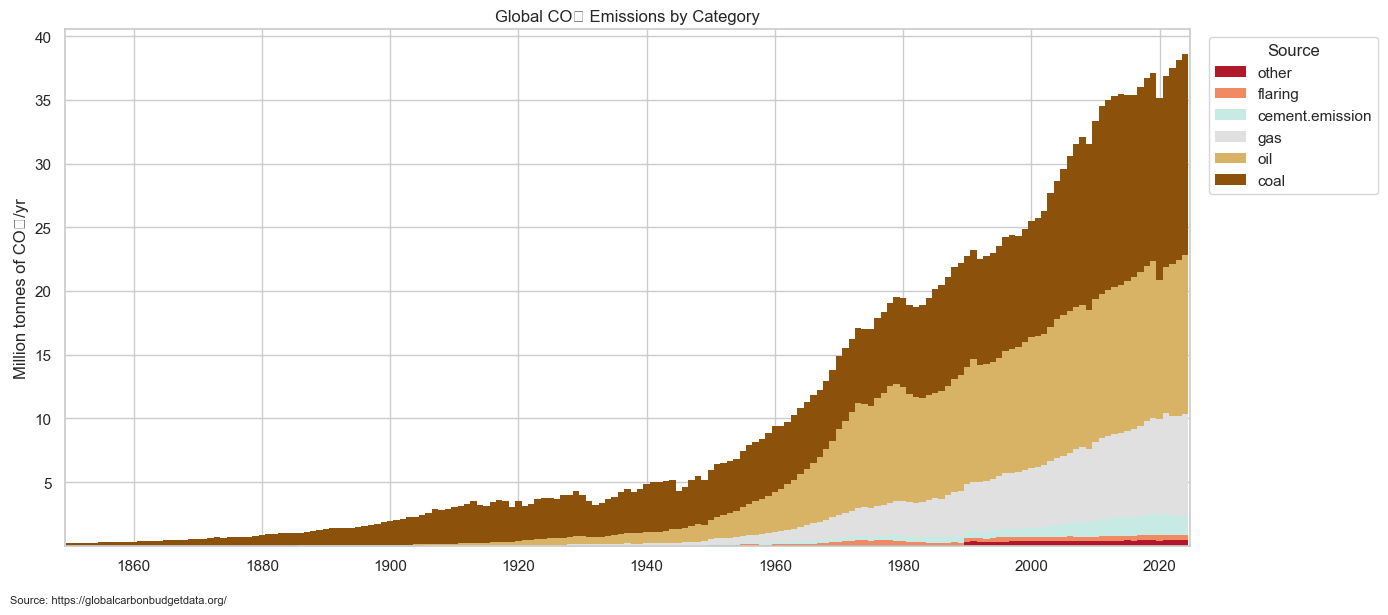

In [14]:
# --- Stacked bar chart: absolute CO2 emissions by year ---
# Each bar represents one year; colours represent emission sources

pivot_abs = (
    global_emissions_long
    .groupby(['year_raw', 'source'], observed=True)['co2_emissions']
    .sum()
    .unstack('source')        # wide format: years as rows, sources as columns
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_abs.plot.bar(
    stacked=True,
    ax=ax,
    color=[colour_map.get(c, 'grey') for c in pivot_abs.columns],
    width=1.0,       # width=1 removes gaps between bars, matching R's width=1
    linewidth=0
)
ax.set_xlabel('')
ax.set_ylabel('Million tonnes of CO₂/yr')
ax.set_title('Global CO₂ Emissions by Category')
ax.legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left')

# Show x-tick labels every 20 years
tick_pos = [i for i, y in enumerate(pivot_abs.index) if int(y) % 20 == 0]
ax.set_xticks(tick_pos)
ax.set_xticklabels([int(pivot_abs.index[i]) for i in tick_pos], rotation=0)

plt.figtext(0.01, -0.02, 'Source: https://globalcarbonbudgetdata.org/', fontsize=8)
plt.tight_layout()
plt.show()

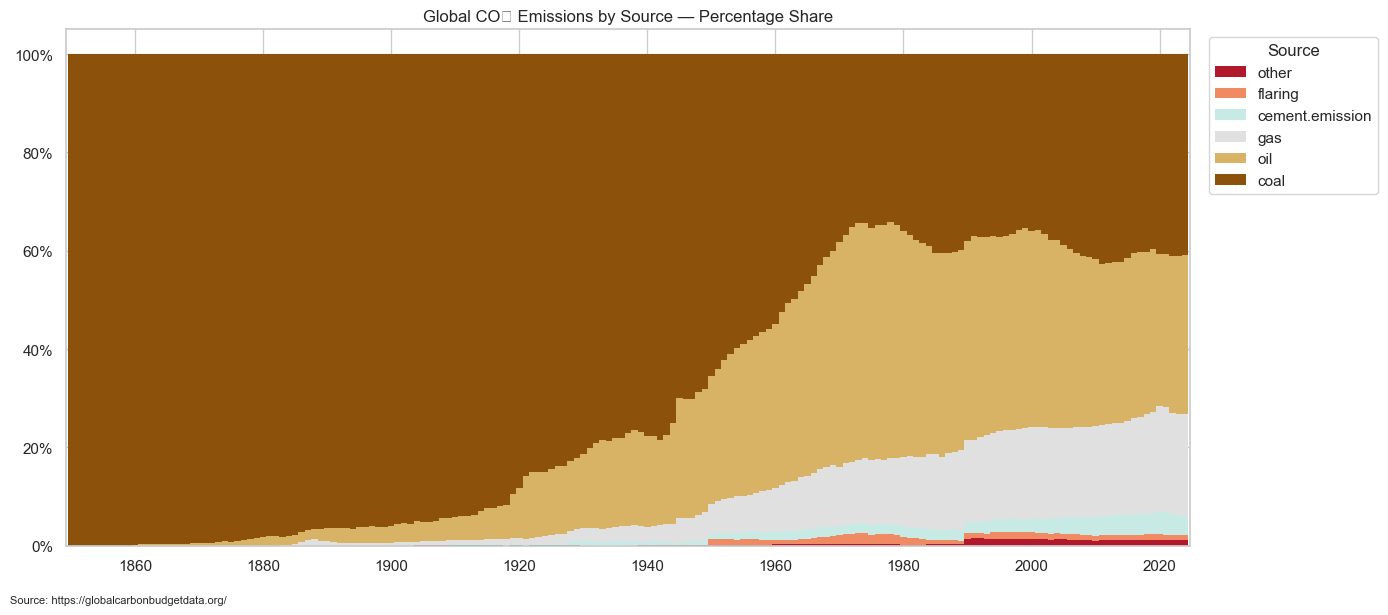

In [15]:
# --- Percentage stacked bar chart: relative share by source ---
# Shows how the *mix* of emission sources has changed over time
# (Oil and gas have grown as a share; coal's dominance has declined)

pivot_pct = pivot_abs.div(pivot_abs.sum(axis=1), axis=0)   # normalise each year to 100%

fig, ax = plt.subplots(figsize=(14, 6))
pivot_pct.plot.bar(
    stacked=True,
    ax=ax,
    color=[colour_map.get(c, 'grey') for c in pivot_pct.columns],
    width=1.0,
    linewidth=0
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Global CO₂ Emissions by Source — Percentage Share')
ax.legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticks(tick_pos)
ax.set_xticklabels([int(pivot_abs.index[i]) for i in tick_pos], rotation=0)
plt.figtext(0.01, -0.02, 'Source: https://globalcarbonbudgetdata.org/', fontsize=8)
plt.tight_layout()
plt.show()

## Part 2 — Carbon Majors Dataset

Emissions attributed to 122 of the world's largest coal, oil, gas, and cement producers (1854–present).

In [16]:
# --- Download Carbon Majors data directly from their website ---
cm_url = 'https://carbonmajors.org/evoke/391/get_cm_file?type=Basic&file=emissions_medium_granularity.csv'

emissions = pd.read_csv(cm_url)
print('Carbon Majors data shape:', emissions.shape)
emissions.head()

Carbon Majors data shape: (14894, 8)


,year,parent_entity,parent_type,lei,commodity,production_value,production_unit,total_emissions_MtCO2e
0,1962,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Oil & NGL,0.91250,Million bbl/yr,0.363885
1,1962,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Natural Gas,1.84325,Bcf/yr,0.134355
2,1963,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Oil & NGL,1.82500,Million bbl/yr,0.727770
3,1963,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Natural Gas,4.42380,Bcf/yr,0.322453
4,1964,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Oil & NGL,7.30000,Million bbl/yr,2.911079


In [17]:
# --- Simplify commodity names: collapse Coal sub-types into 'Coal' ---
# Python equivalent: use regex replace on the commodity column

emissions = (
    emissions
    .assign(
        new_commodity=lambda df: df['commodity'].str.replace(
            r'.*(Coal)$', 'Coal', regex=True
        )
    )
)

print('Distinct new_commodity values:')
print(emissions['new_commodity'].value_counts())

Distinct new_commodity values:
new_commodity
Coal           7093
Oil & NGL      3873
Natural Gas    3629
Cement          299
Name: count, dtype: int64


In [18]:
# --- Order commodities by total emissions ---
cm_levels = (
    emissions
    .groupby('new_commodity')['total_emissions_MtCO2e']
    .sum()
    .sort_values()     # ascending: smallest total first
    .index.tolist()
)

emissions['new_commodity'] = pd.Categorical(
    emissions['new_commodity'], categories=cm_levels, ordered=True
)

# 4 colour palette for 4 commodity categories
cm_colours = ['#c7eae5', '#e0e0e0', '#d8b365', '#8c510a']
cm_colour_map = dict(zip(cm_levels, cm_colours[:len(cm_levels)]))

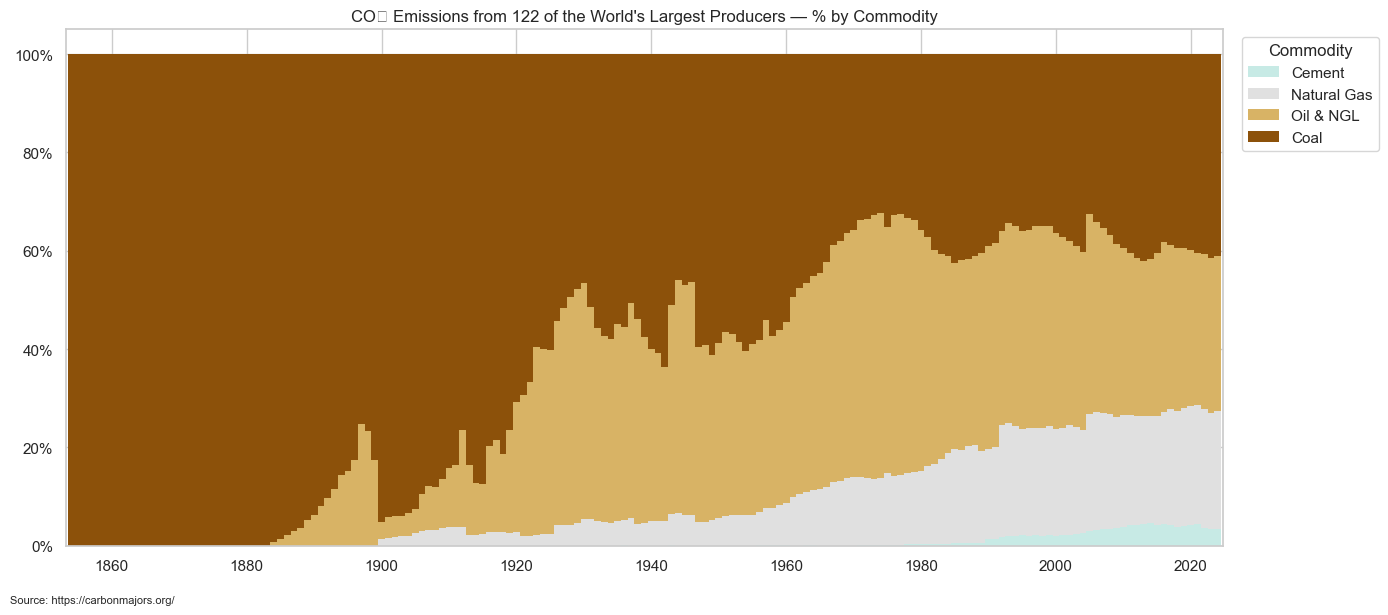

In [19]:
# --- Percentage stacked bar: share of emissions by commodity per year ---

cm_pivot_pct = (
    emissions
    .groupby(['year', 'new_commodity'], observed=True)['total_emissions_MtCO2e']
    .sum()
    .unstack('new_commodity')
    .fillna(0)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0))   # normalise to 100% per year
)

fig, ax = plt.subplots(figsize=(14, 6))
cm_pivot_pct.plot.bar(
    stacked=True,
    ax=ax,
    color=[cm_colour_map.get(c, 'grey') for c in cm_pivot_pct.columns],
    width=1.0,
    linewidth=0
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title("CO₂ Emissions from 122 of the World's Largest Producers — % by Commodity")
ax.legend(title='Commodity', bbox_to_anchor=(1.01, 1), loc='upper left')

tick_pos_cm = [i for i, y in enumerate(cm_pivot_pct.index) if int(y) % 20 == 0]
ax.set_xticks(tick_pos_cm)
ax.set_xticklabels([int(cm_pivot_pct.index[i]) for i in tick_pos_cm], rotation=0)
plt.figtext(0.01, -0.02, 'Source: https://carbonmajors.org/', fontsize=8)
plt.tight_layout()
plt.show()

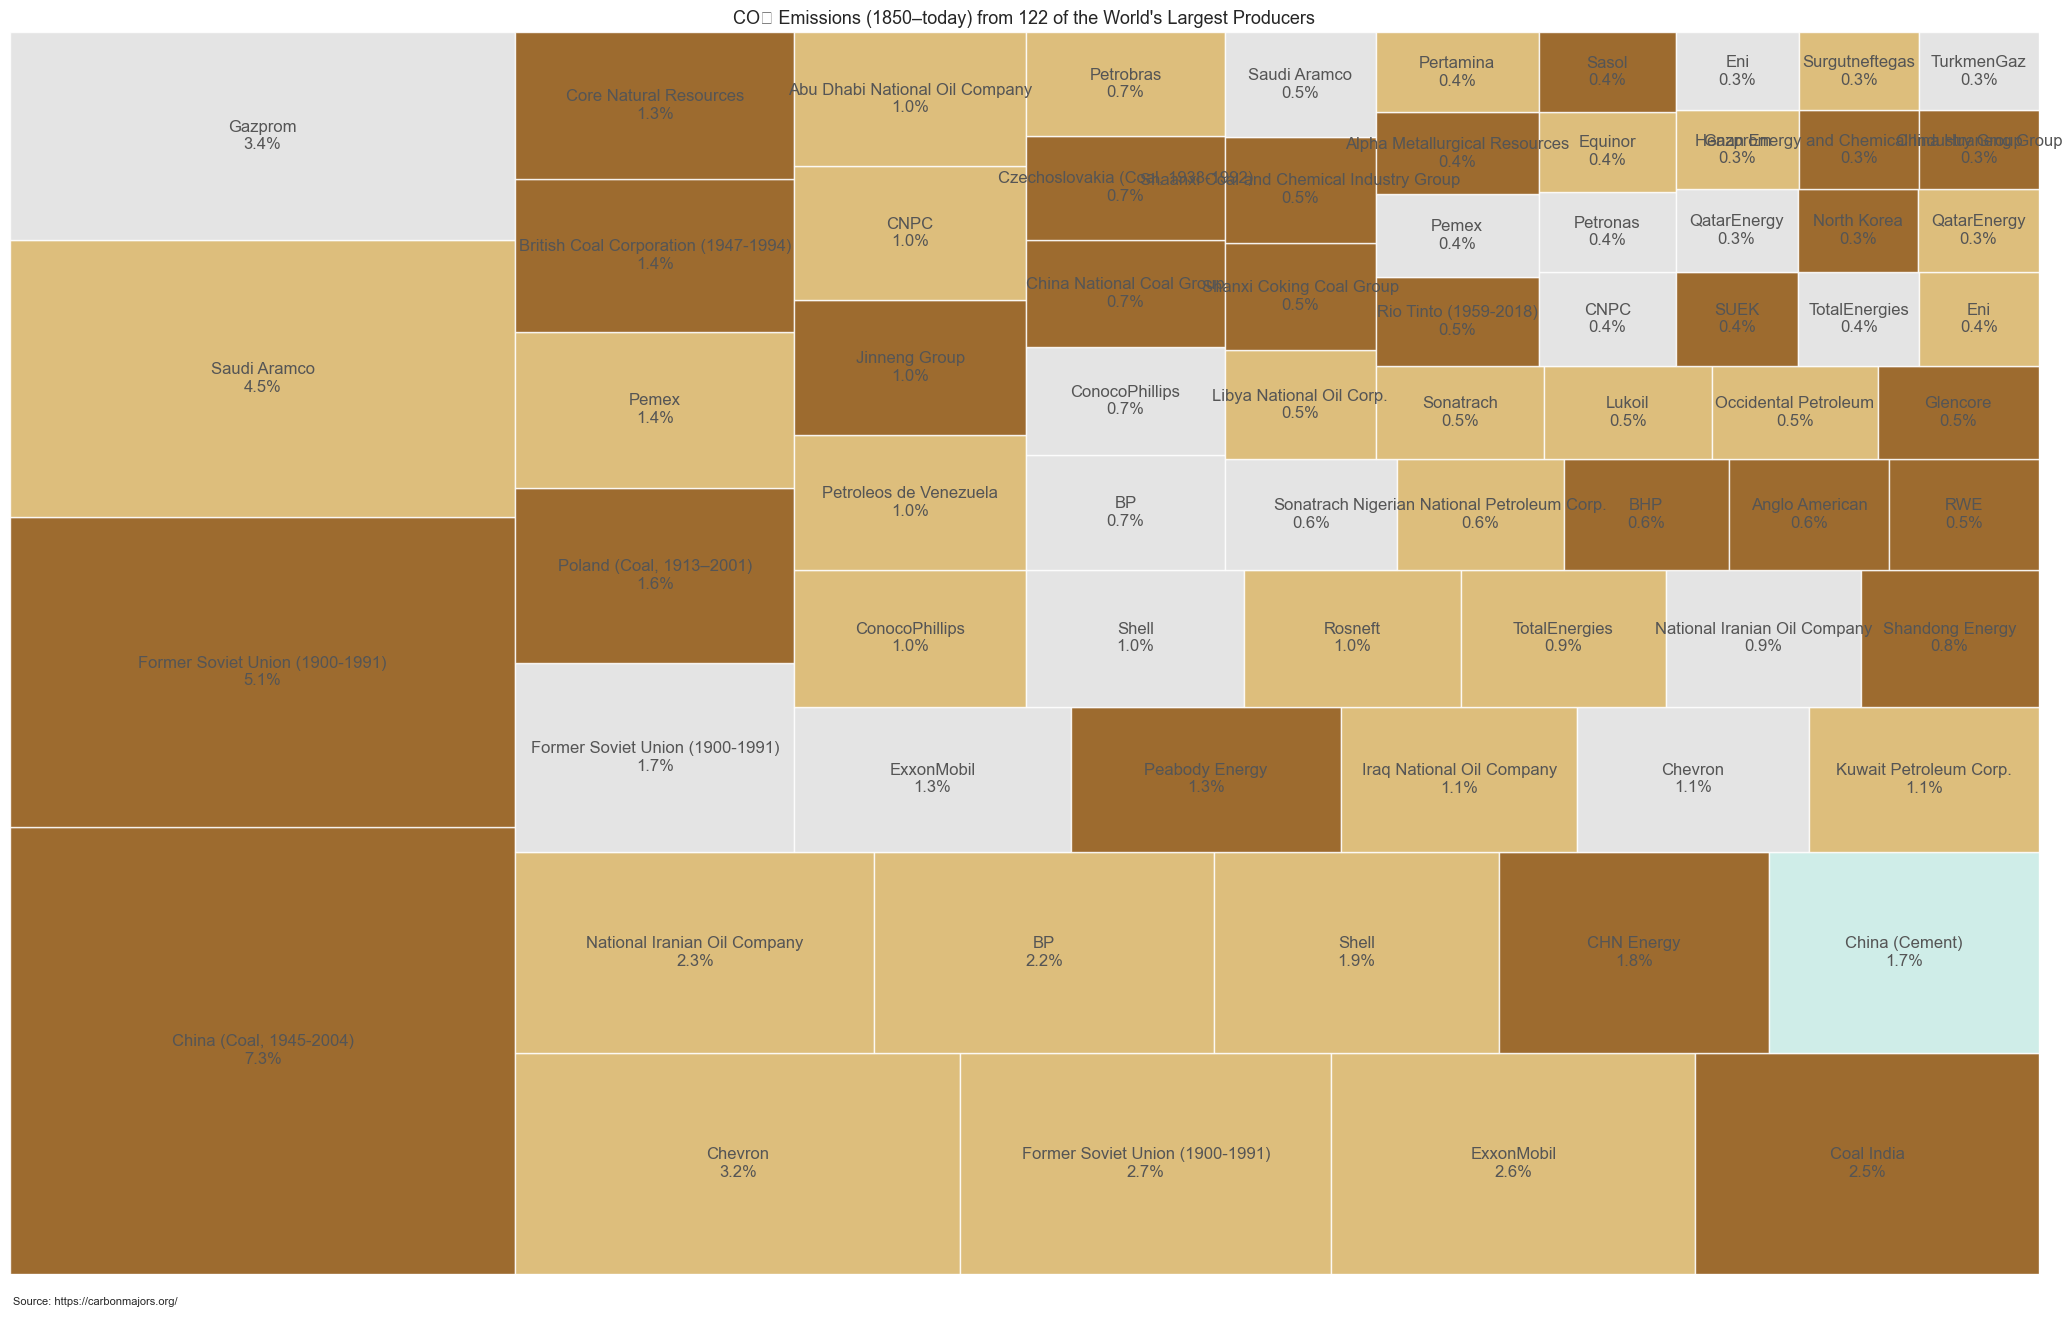

In [ ]:
# --- Treemap: each rectangle = one producer entity, sized by total emissions ---
# Equivalent to geom_treemap() + geom_treemap_text() from ggplot2 treemapify

if squarify is not None:
    treemap_data = (
        emissions
        .groupby(['parent_entity', 'new_commodity'], observed=True)['total_emissions_MtCO2e']
        .sum()
        .reset_index()
        .assign(
            total=lambda df: df['total_emissions_MtCO2e'],
            percent=lambda df: df['total'] / df['total'].sum()
        )
        .query('percent > 0.003')   # <-- filter: only entities > 0.3%

        .sort_values('total', ascending=False)
    )

    # Build label: entity + % (mirrors R's paste(parent_entity, scales::percent(...)))
    treemap_data['label'] = (
        treemap_data['parent_entity'] + '\n' +
        treemap_data['percent'].map(lambda x: f'{x:.1%}')
    )

    # Assign colours based on commodity
    treemap_data['colour'] = treemap_data['new_commodity'].map(cm_colour_map)

    fig, ax = plt.subplots(figsize=(21, 13))
    squarify.plot(
        sizes=treemap_data['total'],
        label=treemap_data['label'],
        color=treemap_data['colour'],
        alpha=0.85,
        text_kwargs={'fontsize': 12, 'color': '#555555'},
        ax=ax
    )
    ax.axis('off')
    ax.set_title("CO₂ Emissions (1850–today) from 122 of the World's Largest Producers",
                 fontsize=13)
    plt.figtext(0.01, -0.01, 'Source: https://carbonmajors.org/', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('Install squarify (pip install squarify) to display the treemap.')

In [27]:
# --- Cleanup temporary file ---
try:
    os.remove(temp_path)
    print('Temp Excel file removed.')
except Exception:
    pass

Temp Excel file removed.
